<a href="https://colab.research.google.com/github/chrisjinyu/distributed-trajectory-planning/blob/main/notebooks/01_admm_verification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Google Colab setup (no-op on local runs)
import sys
import os

if "google.colab" in sys.modules:
    print("Google Colab detected. Setting up environment...")
    print(f"Python: {sys.version_info.major}.{sys.version_info.minor}.{sys.version_info.micro}")

    REPO_URL = "https://github.com/chrisjinyu/distributed-trajectory-planning.git"
    REPO_DIR = "distributed-trajectory-planning"

    if not os.path.exists(REPO_DIR):
        !git clone {REPO_URL}
    else:
        print(f"{REPO_DIR} already exists; pulling latest...")
        !cd {REPO_DIR} && git pull --ff-only

    if os.path.basename(os.getcwd()) != REPO_DIR:
        os.chdir(REPO_DIR)

    # Editable install: installs the package so `from dtp.* import ...` works,
    # and leaves the source tree writable so %autoreload picks up edits.
    !pip install -q -e .

    print("\nColab setup complete.")
else:
    print("Local environment detected. Assuming `uv sync` has already been run.")

Local environment detected. Assuming `uv sync` has already been run.


# Consensus ADMM Verification

Single-MPC-step verification that Consensus ADMM converges to the centralized optimum.

Three experiments, in order of difficulty:
1. Two agents, collision disabled: pure consensus test.
2. Two agents, collision enabled: small real instance.
3. Four agents on a ring, collision enabled: realistic case.

If all three converge to objectives matching the centralized QP (within a fraction of a percent), the ADMM implementation is correct.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from dtp.scenario import Scenario
from dtp.admm import solve_consensus_admm
from dtp.centralized import solve_centralized

In [3]:
# Make the repo root importable so `experiments.runner` resolves.
# Matches the convention used in notebook 02.
import pathlib
_ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == 'notebooks' else pathlib.Path.cwd()
if str(_ROOT) not in sys.path:
    sys.path.insert(0, str(_ROOT))

from experiments.runner import load_scenario, run_admm


## Experiment 1: Two agents, collision disabled

Two drones with goals that do not conflict. With collision off, the joint problem decomposes: each agent can solve its own MPC independently. ADMM's consensus iterations should converge trivially to agents' independent optima.

Why this first: if ADMM fails here, the bug is in the consensus mechanism, not anything to do with collision.

In [4]:
# Two drones starting on opposite sides, goals also on opposite sides (no conflict).
x0 = np.array([
    [-3.0, 0.0, 0.0, 0.0],
    [ 3.0, 0.0, 0.0, 0.0],
])
goals = np.array([
    [ 3.0, 0.0],
    [-3.0, 0.0],
])

scn = Scenario.from_goals(
    x0=x0, goals=goals, H=20, dt=0.2,
    u_max=3.0, d_min=0.5,
    graph=nx.complete_graph(2),
)

result = solve_consensus_admm(
    scn, rho=1.0, max_iter=100, eps_abs=1e-5, eps_rel=1e-4,
    include_collision=False, verbose=False,
)
print(f"ADMM converged: {result.converged} in {result.iterations} iterations")
print(f"Final ADMM objective: {result.history.objective[-1]:.6f}")

ref = solve_centralized(scn, n_ij=None)
print(f"Centralized objective:  {ref.objective:.6f}")
print(f"Relative gap: {abs(result.history.objective[-1] - ref.objective) / abs(ref.objective):.3e}")

ADMM converged: True in 3 iterations
Final ADMM objective: 4459.573830
Centralized objective:  4459.507318
Relative gap: 1.491e-05


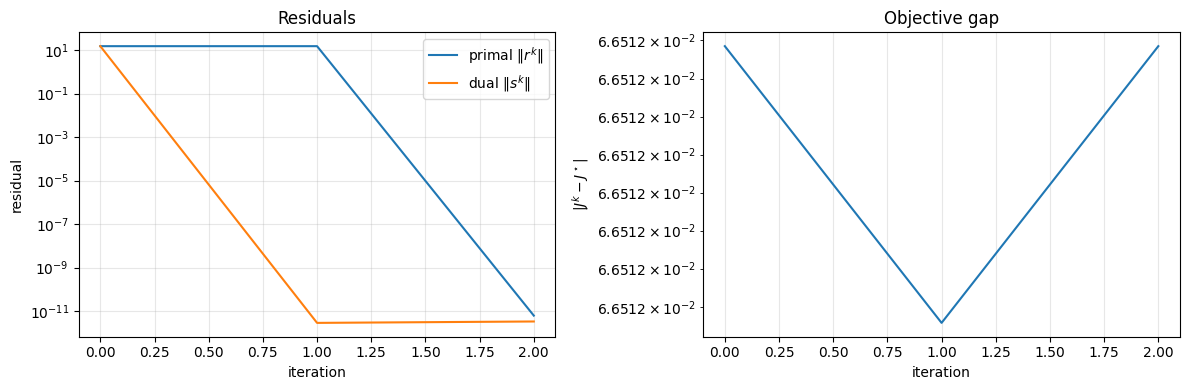

In [5]:
# Convergence plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.semilogy(result.history.primal_residual, label='primal $\\|r^k\\|$')
ax1.semilogy(result.history.dual_residual, label='dual $\\|s^k\\|$')
ax1.set_xlabel('iteration'); ax1.set_ylabel('residual'); ax1.legend(); ax1.set_title('Residuals')
ax1.grid(True, alpha=0.3)

gap = [abs(J - ref.objective) for J in result.history.objective]
ax2.semilogy(gap)
ax2.set_xlabel('iteration'); ax2.set_ylabel('$|J^k - J^\\star|$'); ax2.set_title('Objective gap')
ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## Experiment 2: Two agents, collision enabled

Now the drones must swap sides, so the straight-line paths would collide and collision avoidance is active.

The centralized QP uses collision normals we precompute from a straight-line warm start; ADMM re-linearizes at each iteration.

In [6]:
# Same scenario, now with collision.
result = solve_consensus_admm(
    scn, rho=5.0, max_iter=200, eps_abs=1e-4, eps_rel=1e-3,
    include_collision=True, verbose=False,
)
print(f"ADMM converged: {result.converged} in {result.iterations} iterations")
print(f"Final objective: {result.history.objective[-1]:.6f}")
print(f"Final violation: {result.history.constraint_violation[-1]:.3e}")

# Build centralized reference using ADMM's final linearization.
# This is the fair comparison: both methods see the same affine collision cuts.
from dtp.admm import _update_collision_normals
from dtp.mpc import build_local_qp
tmp_qps = {i: build_local_qp(scn, i) for i in range(scn.N)}
final_normals = _update_collision_normals(scn, tmp_qps, result.x)

ref = solve_centralized(scn, n_ij=final_normals)
print(f"Centralized objective at same linearization: {ref.objective:.6f}")
rel_gap = abs(result.history.objective[-1] - ref.objective) / abs(ref.objective)
print(f"Relative gap: {rel_gap:.3e}")

ADMM converged: True in 56 iterations
Final objective: 4466.635895
Final violation: 0.000e+00
Centralized objective at same linearization: 4466.239632
Relative gap: 8.872e-05


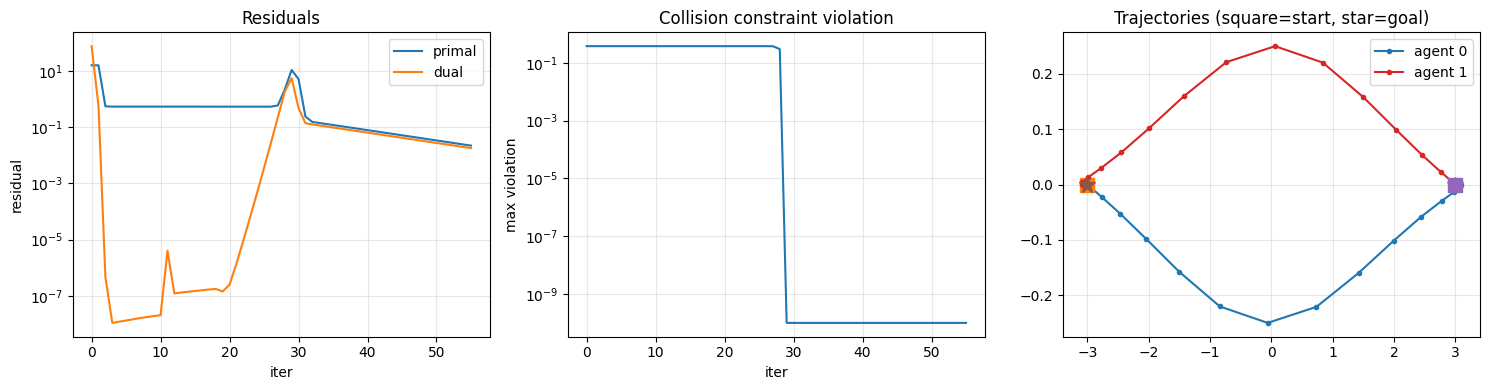

In [7]:
# Plot convergence and trajectories side by side.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].semilogy(result.history.primal_residual, label='primal')
axes[0].semilogy(result.history.dual_residual, label='dual')
axes[0].set_xlabel('iter'); axes[0].set_ylabel('residual'); axes[0].legend()
axes[0].grid(True, alpha=0.3); axes[0].set_title('Residuals')

axes[1].semilogy([max(v, 1e-10) for v in result.history.constraint_violation])
axes[1].set_xlabel('iter'); axes[1].set_ylabel('max violation'); axes[1].grid(True, alpha=0.3)
axes[1].set_title('Collision constraint violation')

for i in range(scn.N):
    p = result.x[i, :, 0:2]
    axes[2].plot(p[:, 0], p[:, 1], '-o', label=f'agent {i}', markersize=3)
    axes[2].plot(scn.x0[i, 0], scn.x0[i, 1], 's', markersize=10)
    axes[2].plot(scn.x_ref[i, -1, 0], scn.x_ref[i, -1, 1], '*', markersize=12)
axes[2].set_aspect('auto'); axes[2].legend(); axes[2].grid(True, alpha=0.3)
axes[2].set_title('Trajectories (square=start, star=goal)')
plt.tight_layout(); plt.show()

## Experiment 3: Four agents on a ring

Symmetric antipodal swap through the center. This is the classic scenario that stresses collision avoidance.

In [8]:
N = 4
radius = 3.0
angles = np.linspace(0, 2 * np.pi, N, endpoint=False)
starts = np.stack([radius * np.cos(angles), radius * np.sin(angles)], axis=1)
goals = -starts  # swap to antipodal point

x0_4 = np.zeros((N, 4))
x0_4[:, 0:2] = starts

scn4 = Scenario.from_goals(
    x0=x0_4, goals=goals, H=25, dt=0.2,
    u_max=3.0, d_min=0.6,
    graph=nx.complete_graph(N),
)

result4 = solve_consensus_admm(
    scn4, rho=5.0, max_iter=300, eps_abs=1e-4, eps_rel=1e-3,
    include_collision=True, verbose=False,
)
print(f"ADMM: converged={result4.converged}, iters={result4.iterations}")
print(f"Final objective: {result4.history.objective[-1]:.4f}")
print(f"Final max violation: {result4.history.constraint_violation[-1]:.3e}")

ADMM: converged=True, iters=59
Final objective: 8956.1990
Final max violation: 2.190e-02


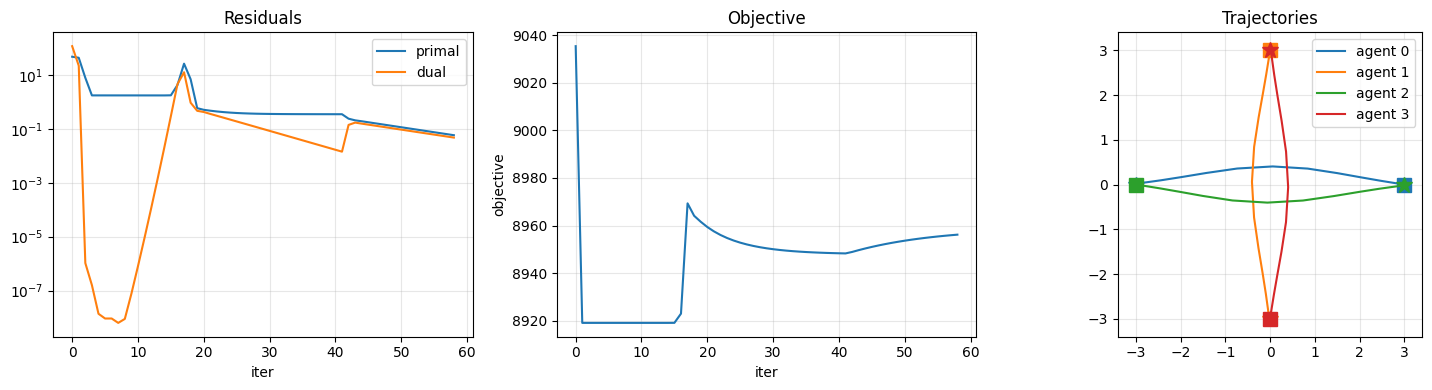

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].semilogy(result4.history.primal_residual, label='primal')
axes[0].semilogy(result4.history.dual_residual, label='dual')
axes[0].set_xlabel('iter'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[0].set_title('Residuals')

axes[1].plot(result4.history.objective)
axes[1].set_xlabel('iter'); axes[1].set_ylabel('objective'); axes[1].grid(True, alpha=0.3)
axes[1].set_title('Objective')

colors = plt.cm.tab10(np.arange(N))
for i in range(N):
    p = result4.x[i, :, 0:2]
    axes[2].plot(p[:, 0], p[:, 1], '-', color=colors[i], label=f'agent {i}')
    axes[2].plot(p[0, 0], p[0, 1], 's', color=colors[i], markersize=10)
    axes[2].plot(goals[i, 0], goals[i, 1], '*', color=colors[i], markersize=12)
axes[2].set_aspect('equal'); axes[2].legend(loc='upper right'); axes[2].grid(True, alpha=0.3)
axes[2].set_title('Trajectories')
plt.tight_layout(); plt.show()

## Sensitivity sweep: $\rho$ vs feasibility gap and iterations (S2)

Two-panel figure mirroring notebook 02's $w$ sweep. Left: max collision
violation at convergence as a function of $\rho$. Right: iterations
until tolerance. Run on the S2 four-drone ring scenario so the $\rho$ and
$w$ sweeps can be compared directly.


rho=   0.10  iters=500  viol=2.551e-01  min_d=0.345


rho=   0.30  iters=500  viol=4.589e-02  min_d=0.554


rho=   1.00  iters=207  viol=1.859e-02  min_d=0.581


rho=   3.00  iters= 66  viol=1.865e-02  min_d=0.581


rho=  10.00  iters= 37  viol=0.000e+00  min_d=0.608


rho=  30.00  iters= 41  viol=7.617e-04  min_d=0.599


rho= 100.00  iters= 51  viol=1.773e-03  min_d=0.598


rho= 300.00  iters=500  viol=4.404e-02  min_d=0.123


rho=1000.00  iters=500  viol=0.000e+00  min_d=0.963


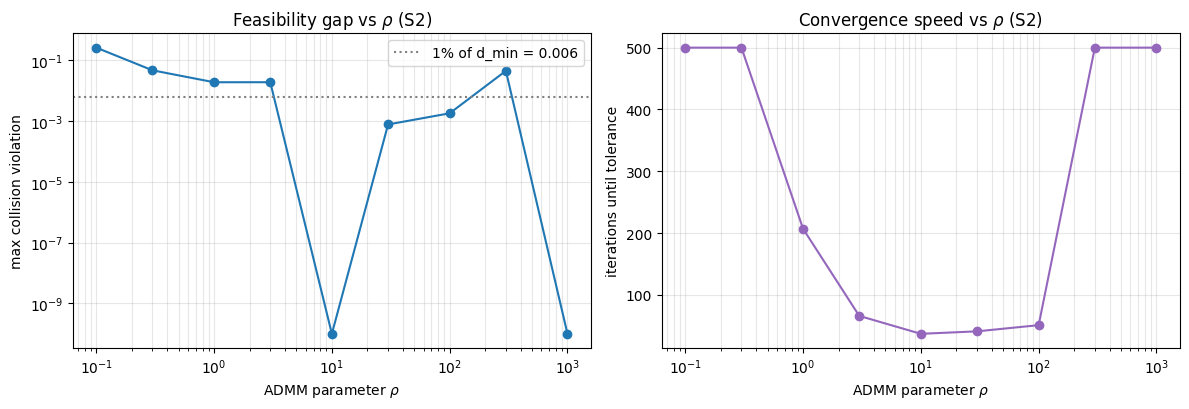

In [10]:
# Sensitivity sweep: rho vs feasibility gap and convergence speed on S2.
# Mirrors notebook 02's w-sweep layout (2-panel figure) so penalty's w and
# ADMM's rho can be compared side by side in the presentation.
scn2 = load_scenario('../experiments/configs/four_drone_ring.yaml')

rhos = [0.1, 0.3, 1.0, 3.0, 10.0, 30.0, 100.0, 300.0, 1000.0]
results = []
for rho in rhos:
    r = run_admm(scn2, rho=rho, max_iter=500, eps_abs=1e-4, eps_rel=1e-3)
    results.append(r)
    print(f"rho={rho:7.2f}  iters={r.iterations:3d}  viol={r.max_collision_violation:.3e}  min_d={r.min_pairwise_distance:.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))
ax1.loglog(rhos, [max(r.max_collision_violation, 1e-10) for r in results], 'o-', color='tab:blue')
ax1.axhline(scn2.d_min * 0.01, color='gray', ls=':', label=f'1% of d_min = {scn2.d_min*0.01:.3f}')
ax1.set_xlabel(r'ADMM parameter $\rho$'); ax1.set_ylabel('max collision violation')
ax1.set_title(r'Feasibility gap vs $\rho$ (S2)')
ax1.legend(); ax1.grid(True, alpha=0.3, which='both')

ax2.semilogx(rhos, [r.iterations for r in results], 'o-', color='tab:purple')
ax2.set_xlabel(r'ADMM parameter $\rho$'); ax2.set_ylabel('iterations until tolerance')
ax2.set_title(r'Convergence speed vs $\rho$ (S2)')
ax2.grid(True, alpha=0.3, which='both')
plt.tight_layout(); plt.show()
